# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [ ]:
from IPython.display import display, HTML, IFrame
import pandas as pd
from pandas import merge

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
transcripts_results_path = f"{output_dir}/ai_bubble_transcripts.xlsx"
filings_results_path = f"{output_dir}/ai_bubble_filings.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [8]:
# AI Bubble Narratives
main_narratives = ['A proposed tax impacting companies employing H-1B visa holders.',
 'New tax may hinder recruitment of skilled H-1B visa workers.',
 'Higher costs may deter companies from hiring H-1B visa candidates.',
 'Companies may prioritize domestic candidates over H-1B visa applicants.',
 'Tax may exacerbate shortages in specialized skills from H-1B visa workers.',
 'Companies may alter recruitment strategies to minimize H-1B visa reliance.',
 'Tax increases operational costs for companies employing H-1B visa workers.',
 'Companies may need to allocate budgets for new H-1B visa taxes.',
 'Increased costs from H-1B visa taxes may reduce profit margins.',
 'Companies may reassess the financial viability of hiring H-1B visa workers.',
 'Companies may restructure operations to offset H-1B visa tax costs.',
 "Tax may affect companies' competitiveness in the global market.",
 'Higher costs may weaken competitiveness against international firms not facing H-1B visa taxes.',
 'Companies may need to adjust pricing due to increased H-1B visa costs.',
 'Competitors may attract H-1B visa talent by offering better conditions.',
 'Companies may need to rethink global strategies to attract H-1B visa talent.',
 'Tax influences long-term workforce planning regarding H-1B visa employees.',
 'Companies may struggle to develop a robust talent pipeline for H-1B visa roles.',
 'Tax may influence decisions to onshore or offshore roles typically filled by H-1B visa workers.',
 'Tax may limit diversity by reducing H-1B visa hiring.',
 'Companies may need to reassess skill requirements due to H-1B visa tax.',
 'Tax may impact innovation driven by H-1B visa talent.',
 'Reduced H-1B visa hiring may limit research and development initiatives.',
 'Tax may disrupt the flow of innovative ideas from H-1B visa workers.',
 'Tax may hinder collaboration with international H-1B visa talent.',
 'Reduced H-1B visa workforce may slow technological advancements.']
 
# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-10"
end_date = "2025-09-23"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'D'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [ ]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

## Run Narrative Mining

Execute the narrative mining processes for news:

In [10]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")

Mining news narratives...


Querying OpenAI...: 100%|██████████| 5697/5697 [04:28<00:00, 21.18it/s]


✅ News mining completed successfully!


# First Labeling

In [145]:
df = news_results["df_labeled"]
print(len(df))
df_sentence_unique = df.drop_duplicates(subset=["Sentence ID"]).reset_index(drop=True)
print(len(df_sentence_unique))


56503
2664


In [146]:
labeler = NarrativeLabeler(llm_model=llm_model)


In [147]:
df_sentence_unique_labeled = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_sentence_unique["Chunk Text"].tolist(),
    titles=df_sentence_unique["Headline"].tolist(),
    mode="theme_matching",
)

Querying OpenAI...:   0%|          | 0/2664 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 2664/2664 [02:14<00:00, 19.75it/s]


In [150]:
df_sentence_unique_labeled.rename(columns={"label": "Theme Matching Label", "motivation": "Theme Matching Motivation"}, inplace=True)
df_sentence_unique_labeled_merged = merge(df_sentence_unique, df_sentence_unique_labeled, left_index=True, right_index=True)


In [153]:
# Select columns from df_sentence_unique_labeled_filtered
columns_to_merge = df_sentence_unique_labeled_merged[['Sentence ID', 'Theme Matching Label', 'Theme Matching Motivation']]

# Merge with df on Sentence ID
df_sentences_merged = df.merge(columns_to_merge, on='Sentence ID', how='left')

df_sentences_related = df_sentences_merged[df_sentences_merged["Theme Matching Label"] != "unclear"]


# Creating the DF

In [170]:
df = df_sentences_related.copy()

In [171]:
df_company = df[df["Entity Type"] == "COMP"]


In [172]:
df_DonaldTrump = df[df["Entity"] == "Donald Trump"]

#Top three People Entities
counts = df[df["Entity Type"] == "PEOP"]["Entity"].value_counts()
top_3 = counts[counts.index != "Donald Trump"].head(3).index.tolist()

top_3_dict_entities = {}
for name in top_3:
    top_3_dict_entities[name] = df[df["Entity"] == name]

print(top_3_dict_entities.keys())


dict_keys(['Howard Lutnick', 'Elon Musk', 'Reed Hastings'])


In [173]:
# Filter for United States
df_US = df[df["Country Code"] == "United States"]

# Get top 5 companies from United States
counts = df_US[df_US["Entity Type"] == "COMP"]["Entity"].value_counts()
top_5_companies_US = counts.head(5).index.tolist()

# Create dictionary with dataframes for each top 5 company
top_5_companies_US_dict = {}
for company in top_5_companies_US:
    top_5_companies_US_dict[company] = df_US[df_US["Entity"] == company]

print(top_5_companies_US_dict.keys())

dict_keys(['Amazon.com Inc.', 'Microsoft Corp.', 'Alphabet Inc.', 'Meta Platforms Inc.', 'JPMorgan Chase & Co.'])


In [174]:
# Get value counts for places excluding India and United States
counts = df[df["Entity Type"] == "PLCE"]["Country Code"].value_counts()
top_3_places = counts[~counts.index.isin(["United States", "India"])].head(3).index.tolist()

# Create dictionary with dataframes for each top 3 place using Country Code
top_3_places_dict = {}
for place in top_3_places:
    top_3_places_dict[place] = df[df["Country Code"] == place]

print(top_3_places_dict.keys())

dict_keys(['China', 'Canada', 'United Kingdom'])


In [175]:
# Create dictionary of dictionaries with top 5 companies for each place
top_3_places_companies = {}

for place in top_3_places:
    df_place = top_3_places_dict[place]
    counts = df_place[df_place["Entity Type"] == "COMP"]["Entity"].value_counts()
    top_5_companies = counts.head(5).index.tolist()
    print(top_5_companies)
    companies_dict = {}
    for company in top_5_companies:
        companies_dict[company] = df_place[df_place["Entity"] == company]
    
    top_3_places_companies[place] = companies_dict

print(top_3_places_companies.keys())

['IBM Corp. Pty. Ltd.', 'Dewang', 'Metaview']
['Thomson Reuters Corp.', 'Talent Fund']
['The Financial Times Ltd.', 'AJ Bell PLC', 'Universities UK', 'HSBC Holdings PLC', 'YouGov PLC']
dict_keys(['China', 'Canada', 'United Kingdom'])


In [176]:
df_India = df[df["Country Code"] == "India"]
counts = df_India[df_India["Entity Type"] == "COMP"]["Entity"].value_counts()
top_5_companies = counts.head(5).index.tolist()

# Create dictionary with dataframes for each top 5 company
top_5_companies_dict = {}
for company in top_5_companies:
    top_5_companies_dict[company] = df_India[df_India["Entity"] == company]

# LABELING

In [177]:
from src.labeler.screener_labeler import ScreenerSummarizerFlex, ScreenerLabelerFlex

In [178]:
# Convert Date column to datetime for proper sorting
df_DonaldTrump_refined = df_DonaldTrump.copy()
df_DonaldTrump_refined['Date'] = pd.to_datetime(df_DonaldTrump_refined['Date'])

# Sort by Date (oldest first)
df_DonaldTrump_refined = df_DonaldTrump_refined.sort_values('Date')

# Remove duplicates keeping the first occurrence (oldest)
df_DonaldTrump_refined = df_DonaldTrump_refined.drop_duplicates(subset='Chunk Text', keep='first')

# Reset index
df_DonaldTrump_refined = df_DonaldTrump_refined.reset_index(drop=True)

print(len(df_DonaldTrump_refined))
print(len(df_DonaldTrump))


374
1261


In [216]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler


In [181]:
df_DonaldTrump_refined.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation'],
      dtype='object')

In [217]:
labeler = NarrativeLabeler(llm_model=llm_model)
df_DT_citation = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_DonaldTrump_refined["Chunk Text"].tolist(),
    titles=df_DonaldTrump_refined["Headline"].tolist(),
    mode="entity_reference",
    entity_track="Donald Trump"
)


Querying OpenAI...:   0%|          | 0/374 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 374/374 [00:32<00:00, 11.57it/s]


In [221]:
df_DT_theme_matching = merge(df_DonaldTrump_refined, df_DT_citation, left_index=True, right_index=True)
df_DT_theme_matching.loc[df_DT_theme_matching["label"] == "unclear", "label"] = "narrative"
df_DT_theme_matching_citation = df_DT_theme_matching[df_DT_theme_matching["label"] == "quote"]
df_DT_theme_matching_citation["label"].value_counts()
df_DT_theme_matching_citation.replace(to_replace="unclear", value="narrative", inplace=True)
df_DT_theme_matching_narrative = df_DT_theme_matching[df_DT_theme_matching["label"] == "narrative"]


/tmp/ipykernel_2896442/513230966.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [222]:
df_DT_theme_matching_narrative["label"].value_counts()

label
narrative    333
Name: count, dtype: int64

In [219]:
for _, row in df_DT_theme_matching_citation.iterrows():
    print(row["Chunk Text"])
    print(row["motivation"])
    print("\n")

"I think they're going to be very happy,
" Trump said, anticipating the tech industry's response to the changes.
Additionally, White House staff secretary Will Scharf said,
"One of the most abused visa systems is the H1-B non-immigrant visa programme. This is supposed to allow highly skilled labourers who work in fields that Americans don't work in to come into the United States of America. What this proclamation will do is raise the fee that companies pay to sponsor H-1B applicants to $100,000. This will ensure that the people they're bringing in are actually very highly skilled and that they're not replaceable by American workers.\"It is noteworthy that Melania Trump, formerly Melania Knauss, received an H-1B visa in October 1996 for modelling work; she hails from Slovenia.
Donald Trump explicitly said, 'I think they're going to be very happy,' which relates to his anticipation of the tech industry's response to the changes regarding H-1B visas.


"We need workers, we need great work

In [228]:
for date in df_DT_theme_matching_citation["Date"].unique():
    print(df_DT_theme_matching_citation[df_DT_theme_matching_citation["Date"] == date]["Chunk Text"].tolist())

['"I think they\'re going to be very happy,\n" Trump said, anticipating the tech industry\'s response to the changes.\nAdditionally, White House staff secretary Will Scharf said,\n"One of the most abused visa systems is the H1-B non-immigrant visa programme. This is supposed to allow highly skilled labourers who work in fields that Americans don\'t work in to come into the United States of America. What this proclamation will do is raise the fee that companies pay to sponsor H-1B applicants to $100,000. This will ensure that the people they\'re bringing in are actually very highly skilled and that they\'re not replaceable by American workers.\\"It is noteworthy that Melania Trump, formerly Melania Knauss, received an H-1B visa in October 1996 for modelling work; she hails from Slovenia.', '"We need workers, we need great workers and this pretty much ensure that that\'s going to happen," Trump said.\nCommerce Secretary Howard Lutnick said that the new fee will prevent companies from tra

In [264]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [239]:
df_DT_theme_matching_citation.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation',
       'motivation', 'label'],
      dtype='object')

In [275]:
narrative_labeler = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
df_DT_theme_matching_citation = df_DT_theme_matching_citation.sort_values('Date')
df_DT_theme_matching_citation["daily summary"] = None
df_DT_theme_matching_citation["daily bullet points"] = None

# Inizializza il dizionario cumulativo
previous_narrative_dict = {}

for date in df_DT_theme_matching_citation["Date"].unique():
    df_temp = df_DT_theme_matching_citation[df_DT_theme_matching_citation["Date"] == date]
    
    # Get daily recap
    daily_recap = narrative_labeler.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_temp,
        mode="temporal_narrative", 
        entity_track="Donald Trump",
        previous_narrative=previous_narrative_dict  # Passa il dizionario
    )
    
    # Extract results
    summary = daily_recap["summary"].iloc[0]
    key_points = daily_recap["key_points"].iloc[0]
    
    # Convert key_points list to string with newlines
    if isinstance(key_points, list):
        key_points_str = "\n".join(key_points)
    else:
        key_points_str = str(key_points) if key_points is not None else ""
    
    print("Summary:", summary)
    print("Key points:", key_points_str)
    
    # Update dataframe - now using the string version
    mask = df_DT_theme_matching_citation["Date"] == date
    df_DT_theme_matching_citation.loc[mask, "daily summary"] = summary
    df_DT_theme_matching_citation.loc[mask, "daily bullet points"] = key_points_str
    
    # Aggiungi al dizionario cumulativo per la prossima iterazione
    if isinstance(key_points, list):
        previous_narrative_dict[date] = summary + "\n" + "\n".join(key_points)
    else:
        previous_narrative_dict[date] = summary + "\n" + str(key_points)

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
The content of the summaries and the bullet points must only be related to the theme 'Introduction of a high fee on H-1B visas'. If some part of the information does not relate to 'Introduction of a high fee on H-1B visas', do not include it in the summary or in the bullet points.

You will receive:
    - Multiple sentences from news articles

Please adhere strictly to the following guidelines:

1. **Task**: 
    - Your task is to analyze today's quotes about 'Donald Trump'

2. **Create an updated summary that**:
    - Primarily focuses on the quotes from 'Donald Trump' 
    - Create a sumamry of the quotes from 'Donald Trump'

3. **Generate bullet points that**:
    - Contain the actual quotes (direct citations) from today's articles
    - Each bullet should include 

Querying OpenAI...: 100%|██████████| 1/1 [00:02<00:00,  2.37s/it]

Summary: Donald Trump expressed confidence that the tech industry will respond positively to the introduction of a high fee on H-1B visas. The new policy aims to ensure that only highly skilled laborers, who are not easily replaceable by American workers, are brought into the United States. The fee increase is part of the Trump administration's broader effort to encourage companies to hire American workers instead of relying on foreign labor.
Key points: "I think they're going to be very happy," Trump said, anticipating the tech industry's response to the changes.
"We need workers, we need great workers and this pretty much ensure that that's going to happen," Trump said.
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
You are also given cumulative narrative summaries from recent past days about 'Donald Trump'. The


Querying OpenAI...: 100%|██████████| 1/1 [00:06<00:00,  6.85s/it]

Summary: Today's quotes provide new insights into the financial implications and strategic intentions behind the introduction of a high fee on H-1B visas. President Trump expects the revised fee-based visa program to generate significant revenue for the US Treasury, aimed at reducing national debt and enabling tax cuts. This aligns with the administration's broader strategy to prioritize American workers by making it financially burdensome for companies to hire foreign talent. Trump reiterated the need for 'great workers' and suggested that the fee ensures only the most valuable foreign workers are retained. The administration's stance is that the fee will incentivize companies to hire domestically, despite concerns from tech entrepreneurs about the sufficiency of homegrown talent. The move is seen as a response to alleged 'systemic abuse' of the H-1B program, which Trump has labeled a 'national security threat.'
Key points: President Trump expects the revised fee-based visa programme 

...

Summary: Today's quotes reinforce the Trump administration's stance on the introduction of a high fee on H-1B visas, emphasizing the policy's intent to curb program abuse, protect American jobs, and address national security concerns. The $100,000 fee is designed to dissuade companies from hiring foreign workers over American workers, aligning with the administration's broader strategy to prioritize domestic employment. This move is consistent with previous statements about the need for 'great workers' and the financial burden placed on companies to ensure only the most valuable foreign talent is retained. The policy has caused significant concern among tech companies and the Indian IT sector, which heavily rely on H-1B visas for skilled labor. As previously stated, the administration views the fee as a mechanism to generate revenue for the US Treasury and reduce national debt, while also addressing alleged 'systemic abuse' of the H-1B program.
Key points: U.S. President Donald Trump o


Querying OpenAI...: 100%|██████████| 1/1 [00:07<00:00,  7.96s/it]

Summary: Today's quotes provide further details on the introduction of a $100,000 fee for H-1B visa applications, a move that has caused significant concern among tech companies and foreign governments. President Trump reiterated the need to impose higher costs on companies to address program abuse while still allowing the hiring of top foreign talent. The fee is intended to incentivize companies to hire American workers and is part of a broader effort to overhaul the H-1B visa program. The White House clarified that the fee is a one-time charge for new petitions, not an annual fee, which has caused some confusion. This aligns with previous statements about prioritizing American workers and addressing alleged systemic abuse of the H-1B program. New information includes the clarification that the fee is a one-time charge and the endorsement from Netflix's Reed Hastings, who supports the fee as a means to reserve visas for high-value jobs, contrasting with the general opposition from Sil


Querying OpenAI...: 100%|██████████| 1/1 [00:04<00:00,  4.93s/it]

Summary: Today's quotes reinforce the Trump administration's stance on the introduction of a $100,000 fee for H-1B visas, emphasizing its potential impact on the tech sector. This move is consistent with previous statements about prioritizing American workers and addressing program abuse. The fee is seen as a significant financial burden for companies, particularly in the tech industry, which heavily relies on foreign talent. As previously stated, the fee aims to ensure that only the most valuable foreign workers are retained, aligning with the administration's broader strategy to protect American jobs and address national security concerns. New information includes Trump's past campaign promise to automatically grant green cards to college graduates, contrasting with the current policy direction.
Key points: US President Donald Trump said on Friday that US companies would need to pay US$100,000 for new H-1B worker visas, a potential blow to the US tech sector.
"You GRADUATE from a col

In [276]:
def generate_daily_recap_html(df, output_file="daily_recap.html"):
    # Get unique dates sorted
    dates = df["Date"].sort_values().unique()
    
    # Start HTML structure
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Daily Recap - H-1B Visa Narrative</title>
        <style>
            body {
                font-family: Arial, sans-serif;
                max-width: 1000px;
                margin: 50px auto;
                padding: 20px;
                background-color: #f5f5f5;
            }
            .date-section {
                background-color: white;
                margin-bottom: 30px;
                padding: 25px;
                border-radius: 8px;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }
            .date-header {
                color: #2c3e50;
                border-bottom: 3px solid #3498db;
                padding-bottom: 10px;
                margin-bottom: 20px;
            }
            .summary {
                color: #34495e;
                line-height: 1.6;
                margin-bottom: 20px;
            }
            .bullet-points {
                background-color: #ecf0f1;
                padding: 15px;
                border-radius: 5px;
                margin-bottom: 20px;
            }
            .bullet-points h3 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 10px;
            }
            .bullet-points ul {
                margin: 0;
                padding-left: 20px;
            }
            .bullet-points li {
                margin-bottom: 8px;
                line-height: 1.4;
            }
            .quotes-section {
                background-color: #f8f9fa;
                padding: 15px;
                border-radius: 5px;
                margin-top: 20px;
                border-left: 4px solid #3498db;
            }
            .quotes-section h3 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 15px;
            }
            .quote-item {
                background-color: white;
                padding: 10px;
                margin-bottom: 10px;
                border-radius: 4px;
                border-left: 3px solid #95a5a6;
                font-style: italic;
                line-height: 1.5;
            }
        </style>
    </head>
    <body>
        <h1>Daily Recap: H-1B Visa Narrative - Donald Trump</h1>
    """
    
    # Add content for each date
    for date in dates:
        date_data = df[df["Date"] == date]
        
        # Handle None values safely
        summary = date_data["daily summary"].iloc[0]
        if summary is None or str(summary).strip() == "" or str(summary) == "nan":
            summary = "No summary available"
            
        bullet_points = date_data["daily bullet points"].iloc[0]
        
        # Get all quotes for this date
        quotes = date_data["Chunk Text"].dropna().unique()
        
        html_content += f"""
        <div class="date-section">
            <h2 class="date-header">{date}</h2>
            <div class="summary">
                <p>{summary}</p>
            </div>
            <div class="bullet-points">
                <h3>Key Points:</h3>
        """
        
        # Handle bullet points properly
        if bullet_points is None or str(bullet_points).strip() == "" or str(bullet_points) == "nan":
            html_content += "<p><em>No key points available</em></p>"
        else:
            # Convert bullet points to proper HTML list
            html_content += "<ul>"
            # Split by newlines and create list items
            points = str(bullet_points).split('\n')
            for point in points:
                point = point.strip()
                if point and point != "":
                    # Remove any existing bullet points (-, *, •)
                    point = point.lstrip('- *•').strip()
                    if point:
                        html_content += f"<li>{point}</li>"
            html_content += "</ul>"
        
        html_content += """
            </div>
            <div class="quotes-section">
        """
        html_content += f"<h3>Source Quotes ({len(quotes)} quotes):</h3>"
        
        # Add each quote
        for i, quote in enumerate(quotes, 1):
            # Handle None or empty quotes
            if quote and str(quote).strip() and str(quote) != "nan":
                html_content += f"""
                <div class="quote-item">
                    <strong>Quote {i}:</strong> {quote}
                </div>
                """
        
        html_content += """
            </div>
        </div>
        """
    
    # Close HTML structure
    html_content += """
    </body>
    </html>
    """
    
    # Save to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"HTML file saved as: {output_file}")
    return output_file

# Usage
generate_daily_recap_html(df_DT_theme_matching_citation)

HTML file saved as: daily_recap.html


'daily_recap.html'

In [243]:
for date in df_DT_theme_matching_citation["Date"].unique():
    df_temp = df_DT_theme_matching_citation[df_DT_theme_matching_citation["Date"] == date]
    print(len(df_temp))

2
8
18
11
2


In [189]:
df_DT_theme_matching_citation["Date"].value_counts()

Date
2025-09-20    83
2025-09-22    73
2025-09-21    70
2025-09-23    34
2025-09-19    10
Name: count, dtype: int64

In [184]:
df_theme_matching_final["Motivation"].iloc[1]

'The sentence discusses a proposed significant increase in application fees for the H-1B visa program, which directly relates to the theme of a proposed tax impacting companies employing H-1B visa holders. The mention of a steep jump in costs for companies hiring foreign talent aligns with the narrative of increased operational costs due to new fees.'

In [90]:
df_theme_matching_final["Chunk Text"].iloc[1]

'The stance reflects Trump\'s broader "America First" agenda, reinforced through a series of executive orders designed to accelerate domestic AI development, push back against what he calls "woke" AI models, and limit dependence on overseas talent.'

In [ ]:
labeler = ScreenerLabelerFlex(llm_model=llm_model)
df_theme_matching = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_sentences["headline"].tolist(),
    texts=df_sentences["masked_text"].tolist(),
    mode = "theme_matching"
)

df_theme_matching_final = merge(df_sentences, df_theme_matching, left_index=True, right_index=True)
df_theme_matching_final = df_theme_matching_final[df_theme_matching_final["label"] != "unclear"]
df_theme_matching_final = df_theme_matching_final.drop(columns=["motivation", "label"])
df_theme_matching_final.reset_index(drop=True, inplace=True)


df_labels = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_theme_matching_final["headline"].tolist(),
    texts=df_theme_matching_final["masked_text"].tolist(),
    mode = "label_classification")

df_labels_final = merge(df_theme_matching_final, df_labels, left_index=True, right_index=True)


df_impact = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_labels_final["headline"].tolist(),
    texts=df_labels_final["masked_text"].tolist(),
    mode = "impact",
    shift_from="no fee",
    shift_to="fee on H-1B visas"
)


df_impact.rename(columns={"label": "Impact Label", "motivation": "Impact Motivation"}, inplace=True)
df_impact_final = merge(df_labels_final, df_impact, left_index=True, right_index=True)


# Merge and process results
df_final = labeler.post_process_dataframe(df_impact_final)
df_final = df_final.drop_duplicates(subset=["Company", "Quote"], keep="first")
df = df_final.drop_duplicates(subset=["Document ID", "Company"], keep="first")

In [17]:
df = news_results["df_labeled"]
df_company = df[df["Entity Type"] == "COMP"]
df_company["Entity"].value_counts()



Entity
Microsoft Corp.                   511
Amazon.com Inc.                   509
Alphabet Inc.                     339
Meta Platforms Inc.               261
Infosys Ltd.                      244
                                 ... 
Dubai Internet City                 1
InCred Financial Services Ltd.      1
CLSA Ltd.                           1
Helios Capital LLC (New York)       1
Most It                             1
Name: count, Length: 170, dtype: int64

## Load and Process Results

Load the exported Excel files, clean the data, and display a summary.

In [18]:
# Load results from all three document types with labeling
news_df = load_results(news_results_path, "News Media")
transcripts_df = load_results(transcripts_results_path, "Earnings Calls")
filings_df = load_results(filings_results_path, "SEC Filings")

# Create and display summary
source_summary = create_source_summary(news_df, transcripts_df, filings_df)
display(source_summary)

# Display sample data from each source
display_sample_data(news_df, transcripts_df, filings_df)

Loaded 56503 narrative records from News Media
Loaded 784 narrative records from Earnings Calls
Loaded 2645 narrative records from SEC Filings


,Source Type,Record Count,Date Range,Unique Narratives
0,News Media,56503,2025-09-10 to 2025-09-23,24
1,Earnings Calls,784,2025-09-10 to 2025-09-18,9
2,SEC Filings,2645,2024-03-25 to 2025-03-28,8



======= SAMPLE NEWS NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
1,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
2,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."



======= SAMPLE EARNINGS CALL NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
1,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
2,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."



======= SAMPLE SEC FILING NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
1,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
2,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...


## Create Narrative Visualizations

Generate comparative visualizations showing narrative evolution across sources and detailed breakdown of news narratives.

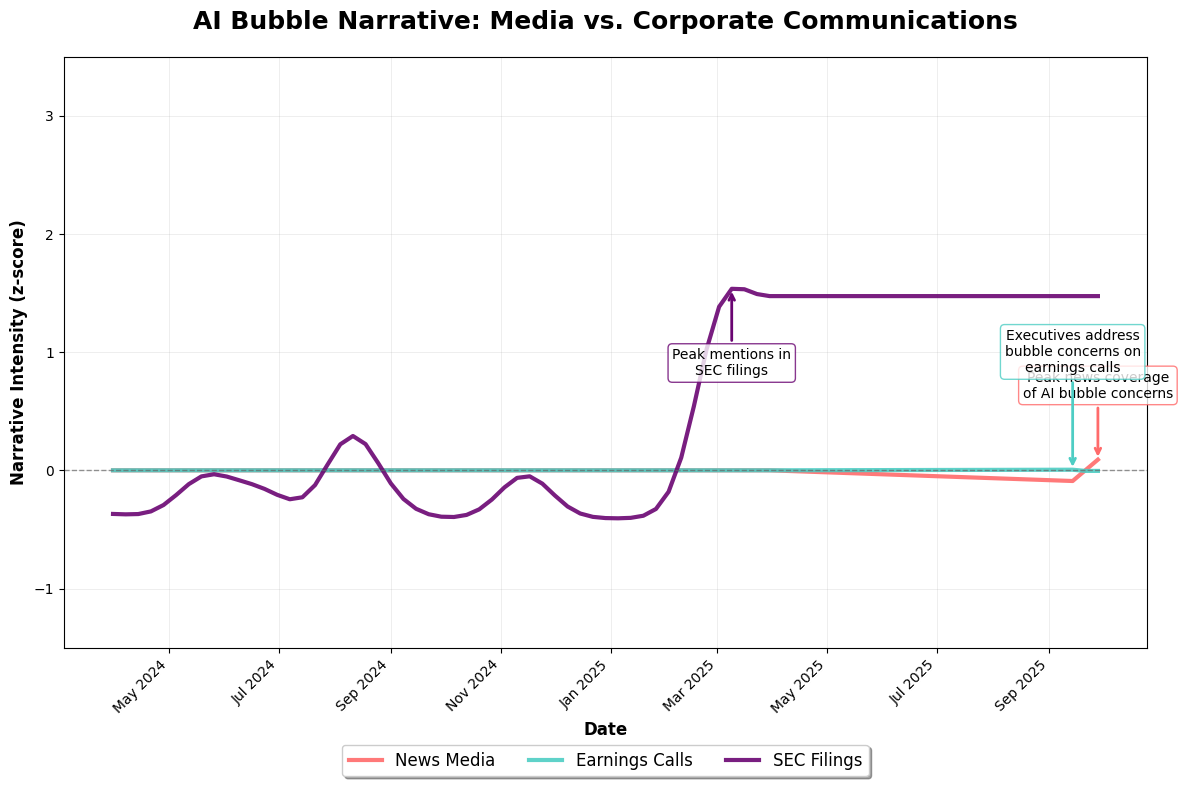

In [19]:
import warnings
warnings.filterwarnings("ignore", message=".*'method'.*", category=FutureWarning)

fig1 = visualize_cross_source_narratives(news_df, transcripts_df, filings_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig1.show()  

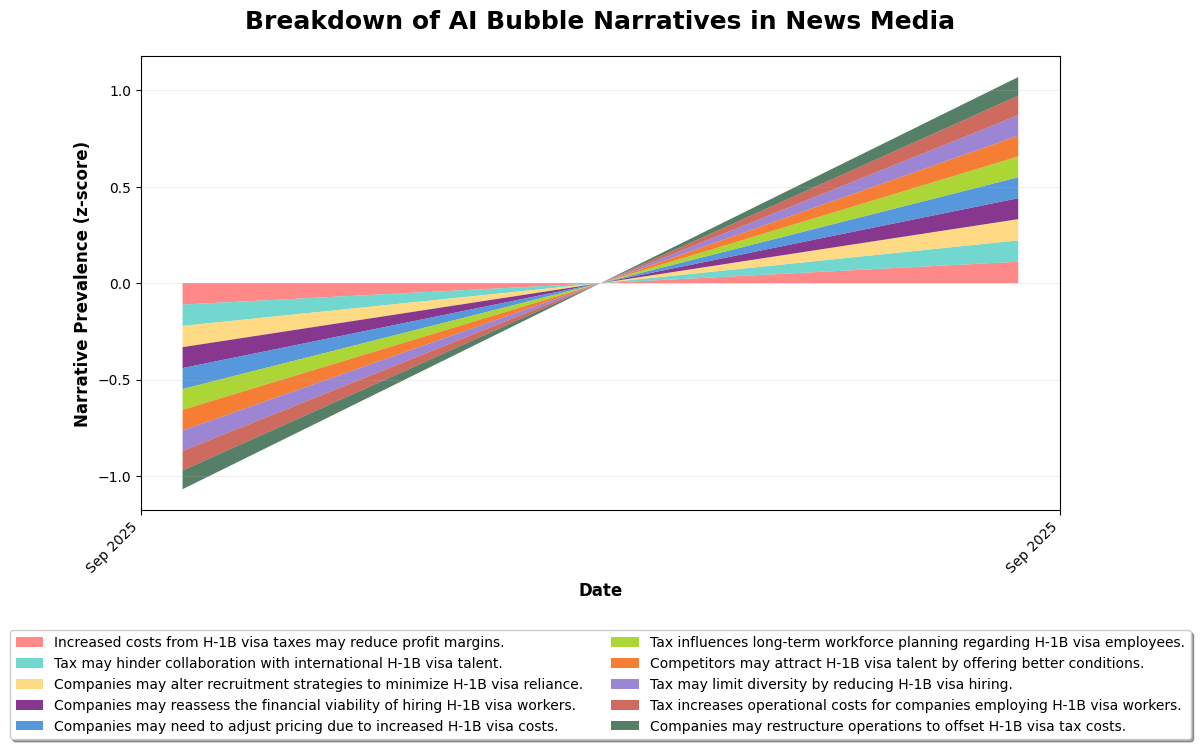

In [20]:
# Create the narrative breakdown visualization for news 
fig2 = visualize_news_narrative_breakdown(news_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig2.show()

## Extract and Display Key Insights

Extract key insights from the narrative mining data and display them.

In [21]:
# Extract insights from our narrative mining data
insights = extract_narrative_insights(news_df, transcripts_df, filings_df)

print("## AI Bubble Narrative Key Insights\n")
print(f"Peak month for news coverage: {insights['peak_news_month']}")
print(f"Peak month for earnings call mentions: {insights['peak_transcript_month']}")
print(f"Peak month for regulatory filing mentions: {insights['peak_filing_month']}")
print(f"\nDominant narrative in news: \"{insights['top_news_narrative']}\"")
print(f"Dominant narrative in earnings calls: \"{insights['top_transcript_narrative']}\"")
print(f"Dominant narrative in regulatory filings: \"{insights['top_filing_narrative']}\"")
print(f"\nTotal narrative mentions in news: {insights['total_news_mentions']}")
print(f"Total mentions in earnings calls: {insights['total_transcript_mentions']}")
print(f"Total mentions in regulatory filings: {insights['total_filing_mentions']}")
print(f"\nAverage lag between news coverage peaks and SEC filings: {insights['avg_lag_days']} days")

## AI Bubble Narrative Key Insights

Peak month for news coverage: September 2025
Peak month for earnings call mentions: September 2025
Peak month for regulatory filing mentions: March 2025

Dominant narrative in news: "A proposed tax impacting companies employing H-1B visa holders."
Dominant narrative in earnings calls: "Companies prefer focusing on long-term strategy"
Dominant narrative in regulatory filings: "Current AI investments may not generate predicted financial returns"

Total narrative mentions in news: 56503
Total mentions in earnings calls: 784
Total mentions in regulatory filings: 2645

Average lag between news coverage peaks and SEC filings: -182 days


## Export the Results

Export the data as Excel files for further analysis or to share with the team.

In [22]:
try:
    # Create the Excel manager
    excel_manager = ExcelManager()

    # Define the dataframes and their sheet configurations
    df_args = [
        (news_df, "News Narratives", (0, 0)),
        (transcripts_df, "Earnings Call Narratives", (0, 0)),
        (filings_df, "SEC Filing Narratives", (0, 0)),
        (source_summary, "Summary", (1, 1))
    ]

    # Save the workbook
    combined_results_path = f"{output_dir}/ai_bubble_narrative_analysis.xlsx"
    excel_manager.save_workbook(df_args, combined_results_path)
    
    print(f"✅ Results exported to {combined_results_path}")

except Exception as e:
    print(f"Warning while exporting to excel: {e}")

✅ Results exported to output/ai_bubble_narrative_analysis.xlsx


## Conclusion

The Narrative Miners reveal important patterns in how the AI bubble narrative evolved across information sources:

**Timing and Intensity Variations:**

- News media shows major spikes in AI bubble concerns, often leading the narrative cycle with the highest peaks
- Earnings calls demonstrate cyclical attention to bubble concerns, with executives addressing topics most prominently during specific quarters
- SEC filings show the most volatile pattern with multiple significant spikes, suggesting ongoing regulatory concerns

**Narrative Progression:**

- Media coverage often leads the initial bubble narrative, potentially triggering corporate responses visible in earnings calls
- Corporate executives' discussions peak during specific periods but tend to diminish over time
- SEC filing mentions frequently show increased intensity throughout the analysis period, indicating persistent regulatory attention

**Cross-Source Intelligence:**

- Different sources provide complementary perspectives on the same underlying narrative
- Timing lags between sources reveal information flow patterns and decision-making hierarchies
- The intensity patterns help identify when narratives are gaining or losing momentum across different stakeholder groups

This analysis demonstrates how systematic narrative mining across multiple document types provides richer insights than analyzing any single source in isolation.